# Quality Control

## Load count matrix

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation
import rpy2
%load_ext rpy2.ipython
import anndata2ri
from rpy2.robjects import r
from rpy2.robjects.conversion import localconverter
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import anndata as ad

rcb.logger.setLevel(logging.ERROR)

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

In [3]:
%%R
library(ensembldb)
library(EnsDb.Hsapiens.v86)
library(SoupX)
library(Seurat)
library(scater)
library(scDblFinder)
library(BiocParallel)
library(SingleCellExperiment)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In [ ]:
%%R -o sce

# Read the empty-drop filtered count matrix RDS file for each sample, combine into a single SingleCellExperiment (SCE) object,
# add gene symbols and full names for each gene Ensembl ID, and output SCE object to Python

# Load Hair_graft_4 count matrix
rds_path1 <- "../../raw_data_processing/results/alevin/mtx_conversions/Hair_graft_4/Hair_graft_4_emptydrops_filter_matrix.sce.rds"
sce_s4_filtered <- readRDS(rds_path1)
# Append sample name to each cell name
colnames(sce_s4_filtered) <- paste0(colnames(sce_s4_filtered), "_", colData(sce_s4_filtered)$sample)

# Load Hair_graft_5 count matrix
rds_path2 <- "../../raw_data_processing/results/alevin/mtx_conversions/Hair_graft_5/Hair_graft_5_emptydrops_filter_matrix.sce.rds"
sce_s5_filtered <- readRDS(rds_path2)
# Append sample name to each cell name
colnames(sce_s5_filtered) <- paste0(colnames(sce_s5_filtered), "_", colData(sce_s5_filtered)$sample)

# Combine the SCE objects for the two samples
sce <- cbind(sce_s4_filtered, sce_s5_filtered)

# Extract Ensembl gene IDs
ensembl_ids <- rownames(sce)

# simpleaf appends -U or -A to Ensembl IDs for unspliced or ambiguous splicing for downstream trajectory inference
# need to clean these IDs before looking up gene symbols/names
getSplicing <- function(ensembl_id) {
    if(endsWith(ensembl_id, "-A")) {
        splicing <- "ambiguous"
    }
    else if(endsWith(ensembl_id, "-U")) {
        splicing <- "unspliced"
    }
    else {
        splicing <- "spliced"
    }
    return(splicing)
}

rowData(sce)$splicing <- as.factor(sapply(ensembl_ids, getSplicing))

# ambiguous <- sapply(ensembl_ids, function(x){endsWith(x, "-A")})
# unspliced <- sapply(ensembl_ids, function(x){endsWith(x, "-U")})



rowData(sce)$clean_ids <- sub("-[AU]$", "", ensembl_ids)


# Convert Ensembl IDs to gene symbols
rowData(sce)$gene_symbol <- mapIds(EnsDb.Hsapiens.v86, 
                       keys = rowData(sce)$clean_ids, 
                       column = "SYMBOL", 
                       keytype = "GENEID", 
                       multiVals = "first")

# Create a new ID using gene symbols where available, Ensembl IDs otherwise, with splicing suffixes
na_symb <- is.na(rowData(sce)$gene_symbol)
rowData(sce)$new_ID <- ensembl_ids
rowData(sce)[(!na_symb)&(rowData(sce)$splicing == "spliced"), 'new_ID'] <- rowData(sce)[(!na_symb)&(rowData(sce)$splicing == "spliced"), 'gene_symbol']
rowData(sce)[(!na_symb)&(rowData(sce)$splicing == "ambiguous"), 'new_ID'] <- paste0(rowData(sce)[(!na_symb)&(rowData(sce)$splicing == "ambiguous"), 'gene_symbol'], "-A")
rowData(sce)[(!na_symb)&(rowData(sce)$splicing == "unspliced"), 'new_ID'] <- paste0(rowData(sce)[(!na_symb)&(rowData(sce)$splicing == "unspliced"), 'gene_symbol'], "-U")



In [30]:
print(sce)

class: SingleCellExperiment 
dim: 236796 5306 
metadata(0):
assays(1): X
rownames(236796): ENSG00000001461 ENSG00000010072 ... ENSG00000310554-A
  ENSG00000310555-A
rowData names(5): gene_versions splicing clean_ids gene_symbol new_ID
colnames(5306): AGATTGCTCCCTCAGT_Hair_graft_4
  CTCGAAACATTCGACA_Hair_graft_4 ... CGATTGATCTGTGCAA_Hair_graft_5
  ACCTTTAGTTTAGGAA_Hair_graft_5
colData names(1): sample
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):



In [48]:
# Convert the SingleCellExperiment object to AnnData object
with localconverter(anndata2ri.converter):
    adata = r('as(sce, "SingleCellExperiment")')

print(adata)

AnnData object with n_obs × n_vars = 5306 × 236796
    obs: 'sample'
    var: 'gene_versions', 'splicing', 'clean_ids', 'gene_symbol', 'new_ID'


In [49]:
adata.var

,gene_versions,splicing,clean_ids,gene_symbol,new_ID
ENSG00000001461,ENSG00000001461,spliced,ENSG00000001461,NIPAL3,NIPAL3
ENSG00000010072,ENSG00000010072,spliced,ENSG00000010072,SPRTN,SPRTN
ENSG00000008118,ENSG00000008118,spliced,ENSG00000008118,CAMK1G,CAMK1G
ENSG00000009780,ENSG00000009780,spliced,ENSG00000009780,FAM76A,FAM76A
ENSG00000048707,ENSG00000048707,spliced,ENSG00000048707,VPS13D,VPS13D
...,...,...,...,...,...
ENSG00000310550-A,ENSG00000310550-A,ambiguous,ENSG00000310550,None,ENSG00000310550-A
ENSG00000310552-A,ENSG00000310552-A,ambiguous,ENSG00000310552,None,ENSG00000310552-A
ENSG00000310553-A,ENSG00000310553-A,ambiguous,ENSG00000310553,None,ENSG00000310553-A
ENSG00000310554-A,ENSG00000310554-A,ambiguous,ENSG00000310554,None,ENSG00000310554-A


In [50]:
adata.var.loc[(adata.var['splicing']=='ambiguous')&(~adata.var['gene_symbol'].isna()),:]

,gene_versions,splicing,clean_ids,gene_symbol,new_ID
ENSG00000001461-A,ENSG00000001461-A,ambiguous,ENSG00000001461,NIPAL3,NIPAL3-A
ENSG00000010072-A,ENSG00000010072-A,ambiguous,ENSG00000010072,SPRTN,SPRTN-A
ENSG00000008118-A,ENSG00000008118-A,ambiguous,ENSG00000008118,CAMK1G,CAMK1G-A
ENSG00000009780-A,ENSG00000009780-A,ambiguous,ENSG00000009780,FAM76A,FAM76A-A
ENSG00000048707-A,ENSG00000048707-A,ambiguous,ENSG00000048707,VPS13D,VPS13D-A
...,...,...,...,...,...
ENSG00000274196-A,ENSG00000274196-A,ambiguous,ENSG00000274196,FAM197Y4P,FAM197Y4P-A
ENSG00000279274-A,ENSG00000279274-A,ambiguous,ENSG00000279274,AC012005.1,AC012005.1-A
ENSG00000280961-A,ENSG00000280961-A,ambiguous,ENSG00000280961,TTTY3B,TTTY3B-A
ENSG00000282909-A,ENSG00000282909-A,ambiguous,ENSG00000282909,RP11-157F24.1,RP11-157F24.1-A


In [ ]:
# merge spliced/unspliced/ambiguous counts
adata_m = adata.copy()
sc.get.aggregate(adata_m, by='clean_ids', func='sum', axis='var')

AnnData object with n_obs × n_vars = 5306 × 78932
    obs: 'sample'
    var: 'clean_ids'
    layers: 'sum'

In [ ]:
# split the matrix into three layers containing spliced/unspliced/ambiguous counts
adata_s = adata[:, adata.var['splicing']=='spliced'].copy()
adata_u = adata[:, adata.var['splicing']=='unspliced'].copy()
adata_a = adata[:, adata.var['splicing']=='ambiguous'].copy()

adata = adata_s.copy()

In [56]:
adata.layers['spliced'] = adata_s.X.copy()
adata.layers['unspliced'] = adata_u.X.copy()
adata.layers['ambiguous'] = adata_a.X.copy()

In [58]:
adata

AnnData object with n_obs × n_vars = 5306 × 78932
    obs: 'sample'
    var: 'gene_versions', 'splicing', 'clean_ids', 'gene_symbol', 'new_ID'
    layers: 'spliced', 'unspliced', 'ambiguous'

In [57]:
del [adata_s, adata_u, adata_a]

In [70]:
adata.var_names = adata.var['clean_ids']

## Filter low quality cells

In [72]:
# mitochondrial genes
adata.var['mt'] = adata.var['gene_symbol'].str.startswith("MT-", na=False)
# ribosomal genes
adata.var['ribo'] = adata.var['gene_symbol'].str.startswith(("RPS", "RPL"), na=False)
# hemoglobin genes
adata.var['hb'] = adata.var['gene_symbol'].str.contains("^HB[^(P)]", na=False)

In [73]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 5306 × 78932
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_versions', 'splicing', 'clean_ids', 'gene_symbol', 'new_ID', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'spliced', 'unspliced', 'ambiguous'

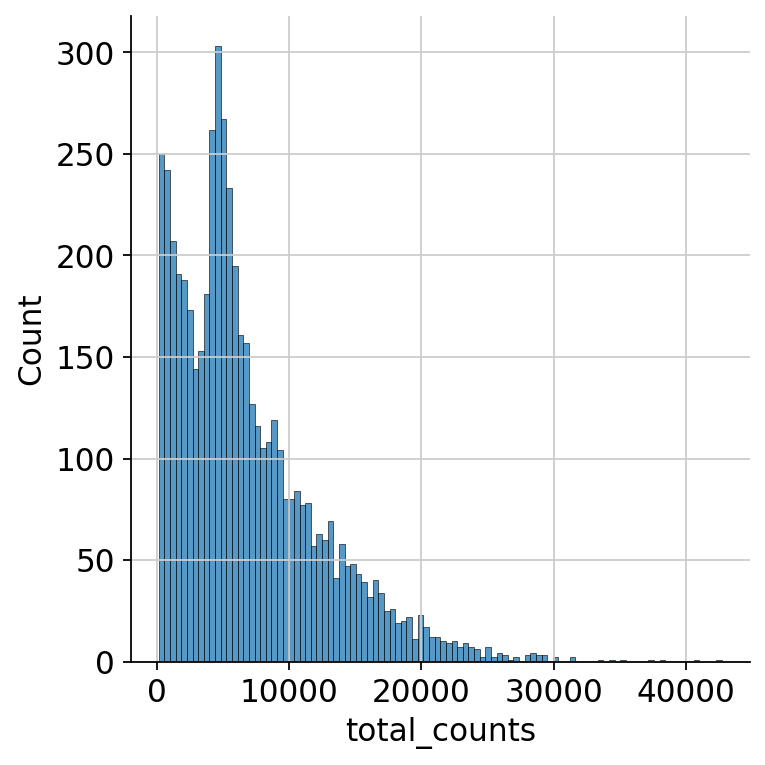

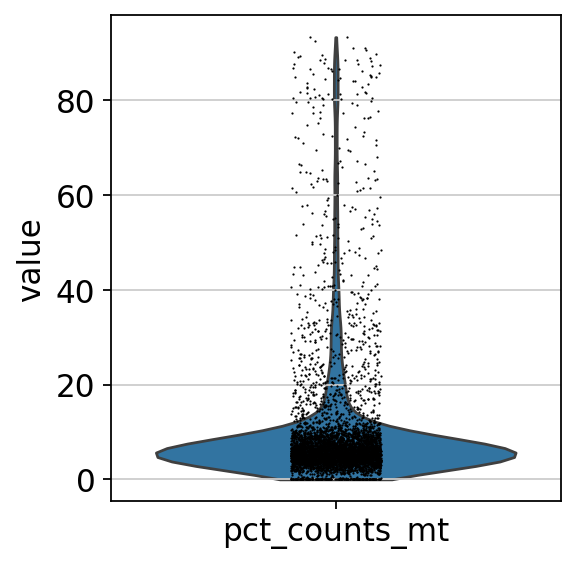

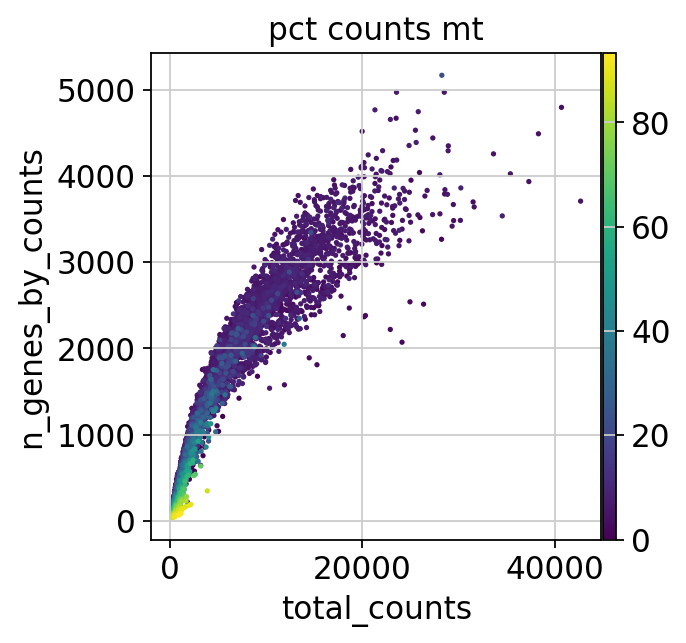

In [74]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [75]:
# Outlier thresholding based on median absolute deviations (MADs)
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [76]:
# apply this function to the log1p_total_counts, log1p_n_genes_by_counts and
# pct_counts_in_top_20_genes QC covariates each with a threshold of 5 MADs
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    4676
True      630
Name: count, dtype: int64

In [77]:
# Mark cells with % mitochondrial counts > 3 MADs
# or mitochondrial counts > 8%
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    3738
True     1568
Name: count, dtype: int64

In [78]:
# filter our AnnData object based on these two additional columns

adata_raw = adata.copy() # save raw / unfiltered data

print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 5306
Number of cells after filtering of low quality cells: 3575


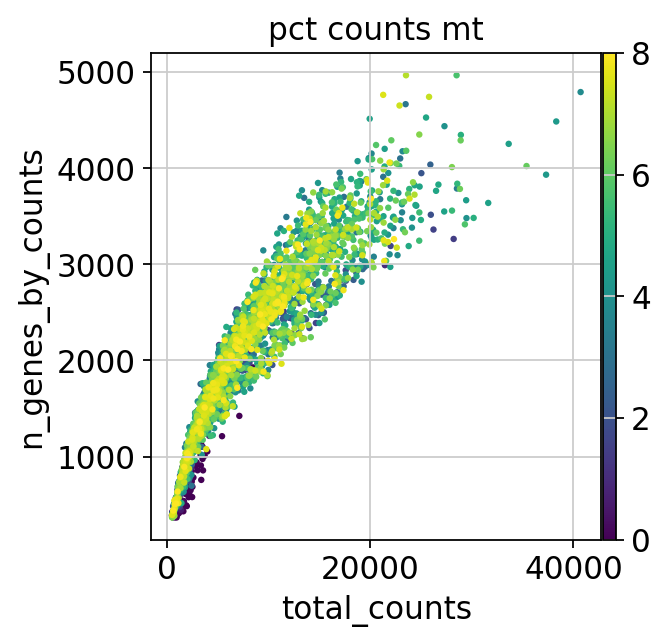

In [79]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Correction of ambient RNA

In [80]:
# generate a copy of our AnnData object, normalize and log1p transform it
adata_pp = adata.copy()
sc.pp.normalize_per_cell(adata_pp)
sc.pp.log1p(adata_pp)

In [81]:
sc.pp.pca(adata_pp) # compute principle components
sc.pp.neighbors(adata_pp) # generate KNN graph
sc.tl.leiden(adata_pp, key_added="soupx_groups") # run leiden clustering

# Preprocess variables for SoupX
soupx_groups = adata_pp.obs["soupx_groups"]

/home/philip/miniconda3/envs/preprocessing/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_103754/2847450567.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_pp, key_added="soupx_groups") # run leiden clustering


In [82]:
# delete AnnData object copy
del adata_pp

In [83]:
# save the cell IDs, gene IDs, and the counts of the filtered count matrix
cells = adata.obs_names
genes = adata.var_names
data = adata.X.T

In [84]:
# SoupX also needs the raw data before any low quality cells were filtered out
data_tod = adata_raw.X.T

In [85]:
with (ro.default_converter + anndata2ri.converter).context():
  r_data = ro.conversion.get_conversion().py2rpy(data)
  r_data_tod = ro.conversion.get_conversion().py2rpy(data_tod)

In [86]:
%%R -i r_data -i r_data_tod -i genes -i cells -i soupx_groups -o r_out 

# specify row and column names of data
data <- r_data
data_tod <- r_data_tod
rownames(data) = genes
colnames(data) = cells
# ensure correct sparse format for table of counts and table of droplets
data <- as(data, "sparseMatrix")
data_tod <- as(data_tod, "sparseMatrix")

# Generate SoupChannel Object for SoupX 
sc = SoupChannel(data_tod, data, calcSoupProfile = FALSE)

# Add extra meta data to the SoupChannel object
soupProf = data.frame(row.names = rownames(data), est = rowSums(data)/sum(data), counts = rowSums(data))
sc = setSoupProfile(sc, soupProf)
# Set cluster information in SoupChannel
sc = setClusters(sc, soupx_groups)

# Estimate contamination fraction
sc  = autoEstCont(sc, doPlot=FALSE)
# Infer corrected table of counts and rount to integer
r_out = adjustCounts(sc, roundToInt = TRUE)

In [88]:
with (ro.default_converter + anndata2ri.converter).context():
  out = ro.conversion.get_conversion().rpy2py(r_out)

In [89]:
# add a new layer to the AnnData object with the SoupX background RNA-corrected count matrix
# and replace the current count matrix with this corrected count matrix
adata.layers["soupX_counts"] = out.T
adata.X = adata.layers["soupX_counts"]

In [91]:
# filter out genes that are not detected in at least 20 cells as these are not informative
print(f"Total number of genes: {adata.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=20)
print(f"Number of genes after cell filter: {adata.n_vars}")

Total number of genes: 78932
Number of genes after cell filter: 15035


## Doublet Detection

In [92]:
data_mat = adata.X.T

In [93]:
with (ro.default_converter + anndata2ri.converter).context():
  r_data_mat = ro.conversion.get_conversion().py2rpy(data)

In [94]:
%%R -i r_data_mat -o r_doublet_score -o r_doublet_class
# Use scDblFinder to detect doublets
set.seed(123)
sce = scDblFinder(
    SingleCellExperiment(
        list(counts=r_data_mat),
    ) 
)
r_doublet_score = sce$scDblFinder.score
r_doublet_class = sce$scDblFinder.class

In [95]:
with (ro.default_converter + anndata2ri.converter).context():
  doublet_score = ro.conversion.get_conversion().rpy2py(r_doublet_score)
  doublet_class = ro.conversion.get_conversion().rpy2py(r_doublet_class)

In [96]:
adata.obs["scDblFinder_score"] = doublet_score
adata.obs["scDblFinder_class"] = doublet_class
adata.obs.scDblFinder_class.value_counts()

scDblFinder_class
singlet    3348
doublet     227
Name: count, dtype: int64

In [97]:
# remove doublets
adata.obs["Doublet"] = adata.obs["scDblFinder_class"]=="doublet"
adata = adata[~adata.obs['Doublet']].copy()

In [98]:
# save the raw combined and QC filtered datasets to file
ad.settings.allow_write_nullable_strings = True
adata_raw.write("raw_combined.h5ad.gz", compression='gzip')
adata.write("quality_control.h5ad.gz", compression='gzip')